# **Sentiment Analysis from Film Reviews Using Deep Learning and Machine Learning Methods**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, roc_curve, auc,
                             classification_report)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM, GRU,
                                      Bidirectional, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)
print("All libraries loaded!")

TensorFlow: 2.20.0
All libraries loaded!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Veri Setleri/Yapay Zeka Dersi/IMDB Dataset.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (50000, 2)

First 5 rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Column names: ['review', 'sentiment']

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


The data consists of two columns: review (movie review) and sentiment (positive/negative). There are 50,000 reviews, split right down the middle — 25,000 positive, 25,000 negative. This is called a balanced dataset, which is a very good thing because the model learns from both classes equally.

## **Data Preprocessing**

In [ ]:
# Clean text function
def clean_text(text):
    text = re.sub(r'<.*?>', '', text) # <br /> gibi HTML etiketlerini sil
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

# Apply cleaning
df['cleaned_review'] = df['review'].apply(clean_text)

# Label encoding
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

print("Dataset shape:", df.shape)
print("Sentiment distribution:")
print(df['sentiment'].value_counts())
print("\nSample cleaned review:")
print(df['cleaned_review'][0][:200])

Dataset shape: (50000, 4)
Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample cleaned review:
one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its br


There were 3 problems with the raw comments:
1. HTML tags → There were things like < br />, these were remnants from the website, they didn't carry any meaning, so we removed them.
2. Case sensitivity → "Good" and "good" are considered two different words by the computer. We converted them all to lowercase so that it recognizes them as the same word.
3. Punctuation → "good!" and "good" were again considered different. We removed the punctuation marks.
As a result, the comment became cleaner and more organized. The computer can now focus on the word.

The model doesn't understand the words "positive" or "negative," it only understands numbers. LabelEncoder converts these to 0 and 1 → negative = 0, positive = 1.

The dataset shape became 50000 × 4 because `cleaned_review` and `label` columns were added alongside the original two columns.

## **Train/Test Split**

In [ ]:
# Train/test split
X = df['cleaned_review'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Tokenization parameters
MAX_WORDS = 20000
MAX_LEN = 300

# Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)
print("y_train unique:", np.unique(y_train))
print("y_test unique:", np.unique(y_test))

Train size: 40000
Test size: 10000
X_train_pad shape: (40000, 300)
X_test_pad shape: (10000, 300)
y_train unique: [0 1]
y_test unique: [0 1]


We divided the data into two parts. Because we used `stratify=y`, the positive/negative ratio remained equal in both parts. This means the model didn't learn by only seeing positive comments; it learned in a balanced way.

Tokenization: The model processes numbers, not words. The tokenizer assigns a number to each word.

Example:

"this movie was great" → [4, 12, 8, 156]

num_words=20000 → Take the 20,000 most frequently used words, ignore the rest.

< OOV > → An "out of vocabulary" or special placeholder is assigned to unknown words.

Padding:

Each comment has a different length. The model expects input of the same size, so they are all set to a length of 300:

Short comments → a 0 is added to the end (padding)

Long comments → truncating is done beyond 300

As a result, the size of X_train_pad is (40000, 300) — meaning 40,000 comments, each a sequence of 300 numbers.

## **GloVe Upload and Embedding Matrix**

What is GloVe?

In a normal model, words are simply converted into numbers:

"king" → 4

"queen" → 7

"cat" → 892

These numbers are completely independent of each other — the model doesn't know that "king" and "queen" are related.

GloVe, however, represents words not as numbers, but as a vector of 100 numbers:

"king" → [0.50, -0.23, 0.87, 0.12, ...] (100 numbers)

"queen" → [0.48, -0.21, 0.85, 0.14, ...] (100 numbers)

"cat" → [-0.30, 0.92, -0.11, 0.67, ...] (100 numbers)

The vectors "king" and "queen" are very close to each other because GloVe learned how often the words appear together by reading millions of English texts. In other words, he knows the semantic relationships between words numerically.

In [ ]:
EMBEDDING_DIM = 100

# Load GloVe
glove_embeddings = {}
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype='float32')
        glove_embeddings[word] = vector

print(f"GloVe words loaded: {len(glove_embeddings)}")

# Create embedding matrix
embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))
found = 0
for word, index in tokenizer.word_index.items():
    if index < MAX_WORDS:
        vector = glove_embeddings.get(word)
        if vector is not None:
            embedding_matrix[index] = vector
            found += 1

print(f"Words found in GloVe: {found} / {MAX_WORDS}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

GloVe words loaded: 400000
Words found in GloVe: 19305 / 20000
Embedding matrix shape: (20000, 100)


Each line of the file is as follows: king 0.50 -0.23 0.87 ...
The code reads this and saves it to a dictionary → {"king": [0.50, -0.23, ...], "queen": ...}

400,000 words loaded — that's the total number of words GloVe knows.

Creating an embedding matrix:

GloVe words loaded: 400,000 → GloVe's total vocabulary

Words found in GloVe: 19,305 / 20,000 → 19,305 of our 20,000 words were found in GloVe

Embedding matrix shape: (20,000, 100) → 20,000 words × 100-dimensional vector

96.5% match — that's a very good rate!

Only 695 words remained as zero vectors, these are probably very rare or misspelled words.

## **Evaluate Function and Results Dictionary**

We wrote a single measurement function to test each model we trained. There will be four models (RNN, LSTM, BiLSTM, GRU), and instead of writing one for each, we will call this function.

In [ ]:
# Store all results here
results = {}

def evaluate_model(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    results[model_name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'y_pred': y_pred,
        'y_pred_prob': y_pred_prob
    }

    print(f"\n{'='*40}")
    print(f"{model_name} Results:")
    print(f"{'='*40}")
    print(f"Accuracy:  {results[model_name]['accuracy']:.4f}")
    print(f"Precision: {results[model_name]['precision']:.4f}")
    print(f"Recall:    {results[model_name]['recall']:.4f}")
    print(f"F1 Score:  {results[model_name]['f1']:.4f}")

print("Evaluate function ready!")

Evaluate function ready!


What do the metrics mean:

Accuracy - How many predictions did it make correctly overall?

Precision - How many of the "positive" predictions were actually positive?

Recall - How many true positives did it capture?

F1 Score - A balanced average of Precision and Recall

In sentiment analysis, the F1 Score is often considered the most important metric because it provides a balanced assessment of both precision and recall.

## **Simple RNN Model**

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

rnn_model = Sequential([
    Embedding(MAX_WORDS, EMBEDDING_DIM,
              weights=[embedding_matrix],
              trainable=True),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

evaluate_model(rnn_model, X_test_pad, y_test, 'Simple RNN')

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.5085 - loss: 0.7076 - val_accuracy: 0.5045 - val_loss: 0.6936
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.5165 - loss: 0.7012 - val_accuracy: 0.5069 - val_loss: 0.6920
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.5225 - loss: 0.6896 - val_accuracy: 0.5194 - val_loss: 0.6887
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.5290 - loss: 0.6954 - val_accuracy: 0.5036 - val_loss: 0.6937
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.5091 - loss: 0.6954 - val_accuracy: 0.5059 - val_loss: 0.6924
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.5171 - loss: 0.6908 - val_accuracy: 0.5075 - val_loss: 0.6920

Simple RNN Results:
Accuracy:  0.5082
Precision: 0.5050
Recall:    0.8292
F1 Score:  0.6277


It stopped at Epoch 6 because 'val_accuracy' didn't improve for 3 epochs (patience = 3). The best weights were restored.

Accuracy remained stuck in the 50-52% range.

Recall is high but precision is very low — what does this mean?

The model labels almost everything as "positive" It captures true positives (83%) but also counts negatives as positives. In other words, it can't differentiate; it employs a "treat everything as positive" strategy.

Simple RNNs cannot remember long texts.

Movie reviews can be up to 300 words long. When the RNN reads the sentence from left to right, by the time it reaches the 300th word, it has forgotten the information from the first word. This is called the vanishing gradient problem.

Therefore, LSTM was invented to help people remember long-term addictions.

## **LSTM Model**

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

lstm_model = Sequential([
    Embedding(MAX_WORDS, EMBEDDING_DIM,
              weights=[embedding_matrix],
              trainable=True),
    Conv1D(128, 5, activation='relu'),
    MaxPooling1D(5),
    LSTM(128),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

evaluate_model(lstm_model, X_test_pad, y_test, 'LSTM')

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6887 - loss: 0.5562 - val_accuracy: 0.8476 - val_loss: 0.3581
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8819 - loss: 0.2995 - val_accuracy: 0.8906 - val_loss: 0.2724
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9161 - loss: 0.2267 - val_accuracy: 0.8953 - val_loss: 0.2678
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9389 - loss: 0.1763 - val_accuracy: 0.8681 - val_loss: 0.3040
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9536 - loss: 0.1467 - val_accuracy: 0.8205 - val_loss: 0.3826
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9628 - loss: 0.1183 - val_accuracy: 0.8840 - val_loss: 0.2882

LSTM Results:
Accuracy:  0.8954
Precision: 0.9012
Recall:    0.8882
F1 Score:  0.8946


Epoch 3: Best val_accuracy.

Epoch 4: Decreased

Epoch 5: Further decreased

Epoch 6: 3 epochs of no improvement -> stopped

Train reached 96% while val remained at 90% - overfitting was more pronounced. The model memorizes the training data very well, but it doesn't always translate this to new data. Early stopping restored the best weights (Epoch 3).

## **BiLSTM Model (Bidirectional LSTM)**

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

bilstm_model = Sequential([
    Embedding(MAX_WORDS, EMBEDDING_DIM,
              weights=[embedding_matrix],
              trainable=True),
    Conv1D(128, 5, activation='relu'),
    MaxPooling1D(5),
    Bidirectional(LSTM(128)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

bilstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

bilstm_history = bilstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

evaluate_model(bilstm_model, X_test_pad, y_test, 'BiLSTM')

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.7570 - loss: 0.4774 - val_accuracy: 0.8629 - val_loss: 0.3211
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8957 - loss: 0.2613 - val_accuracy: 0.8851 - val_loss: 0.2764
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9210 - loss: 0.2072 - val_accuracy: 0.8942 - val_loss: 0.2592
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9411 - loss: 0.1590 - val_accuracy: 0.8832 - val_loss: 0.3006
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9512 - loss: 0.1353 - val_accuracy: 0.8740 - val_loss: 0.3559
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9628 - loss: 0.1063 - val_accuracy: 0.8609 - val_loss: 0.4116

BiLSTM Results:
Accuracy:  0.8965
Precision: 0.8815
Recall:    0.9162
F1 Score:  0.8985


Normal LSTM reads a sentence only from left to right.

Bidirectional LSTM reads the same sentence from both directions.

It combines information from both readings.

In a phrase like "not good," the word "not" comes before "good." Normal LSTM recognizes "not" when it reaches "good," but it might forget it as it progresses. Backward LSTM, however, starts from "good" and reaches "not"—capturing the context from both directions.

Epoch 3: Peak

Epoch 4: Decreased

Epoch 6: No improvement in 3 epochs -> Stopped

The same overfitting pattern is present here. While Train reached 96%, Val remained at 89%. The fact that it started higher than other models in Epoch 1 indicates that BiLSTM learned faster.

BiLSTM is currently the overall leader. They have pulled ahead in Accuracy and F1.

## **GRU Model**

A simpler version of LSTM. Both are designed to remember long dependencies, but they have different gate mechanisms.

LSTM: 3 doors -> input, forget, output

GRU: 2 doors -> reset, update

LSTM has more parameters and is slower.

GRU does similar work with fewer parameters.

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

gru_model = Sequential([
    Embedding(MAX_WORDS, EMBEDDING_DIM,
              weights=[embedding_matrix],
              trainable=True),
    Conv1D(128, 5, activation='relu'),
    MaxPooling1D(5),
    GRU(128),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

gru_history = gru_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

evaluate_model(gru_model, X_test_pad, y_test, 'GRU')

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5728 - loss: 0.6631 - val_accuracy: 0.7794 - val_loss: 0.5007
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8672 - loss: 0.3210 - val_accuracy: 0.8832 - val_loss: 0.2807
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9196 - loss: 0.2142 - val_accuracy: 0.8903 - val_loss: 0.2687
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9421 - loss: 0.1602 - val_accuracy: 0.8984 - val_loss: 0.2730
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9591 - loss: 0.1186 - val_accuracy: 0.8461 - val_loss: 0.4751
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9629 - loss: 0.1041 - val_accuracy: 0.8382 - val_loss: 0.4430
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9690 - loss: 0.0872 - val_accuracy: 0.8834 - val_loss: 0.3293

GRU Results:
Accuracy:  0.9013
Precision: 0.9049
Recall:    0.8968
F1 Score:  0.9009


Epoch 1: Slow start

Epoch 2: Big jump

Epoch 4: Peak

Epoch 5: Sharp drop

Epoch 7: No recovery for 3 epochs -> stopped, returned to Epoch 4

Epoch 1 started significantly lower than the others - GRU had a somewhat unlucky start with random starting weights. But they recovered quickly in Epoch 2. There's severe overfitting between Epochs 4-5: train dropped to 96%, val to 85%. Early stopping restored the weights of Epoch 4.

Final: GRU won. It outperformed all other models in Accuracy and F1. The fact that it achieved better results with fewer parameters shows that GRU is a good fit for this dataset.

## **Machine Learning Comparison**

In [ ]:
# TF-IDF feature extraction
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, lr_pred),
    'precision': precision_score(y_test, lr_pred),
    'recall': recall_score(y_test, lr_pred),
    'f1': f1_score(y_test, lr_pred),
    'y_pred': lr_pred,
    'y_pred_prob': lr_model.predict_proba(X_test_tfidf)[:,1]
}

# SVM
svm_model = LinearSVC(max_iter=1000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

results['SVM'] = {
    'accuracy': accuracy_score(y_test, svm_pred),
    'precision': precision_score(y_test, svm_pred),
    'recall': recall_score(y_test, svm_pred),
    'f1': f1_score(y_test, svm_pred),
    'y_pred': svm_pred,
    'y_pred_prob': None
}

print("Logistic Regression Results:")
print(f"Accuracy:  {results['Logistic Regression']['accuracy']:.4f}")
print(f"Precision: {results['Logistic Regression']['precision']:.4f}")
print(f"Recall:    {results['Logistic Regression']['recall']:.4f}")
print(f"F1 Score:  {results['Logistic Regression']['f1']:.4f}")

print("\nSVM Results:")
print(f"Accuracy:  {results['SVM']['accuracy']:.4f}")
print(f"Precision: {results['SVM']['precision']:.4f}")
print(f"Recall:    {results['SVM']['recall']:.4f}")
print(f"F1 Score:  {results['SVM']['f1']:.4f}")

Logistic Regression Results:
Accuracy:  0.9021
Precision: 0.8948
Recall:    0.9114
F1 Score:  0.9030

SVM Results:
Accuracy:  0.9001
Precision: 0.8939
Recall:    0.9080
F1 Score:  0.9009


Deep Learning: Word -> number sequence -> derive meaning using LSTM memory

ML models: Word -> TF-IDF table -> find statistical patterns

TF-IDF captures both single words and pairs of words. Phrases like "not good" and "very bad" are captured as single words – this is crucial because "good" alone is positive, but "not good" is negative.

The biggest surprise of this project: Logistic Regression came in first!

Why Did Deep Learning Fall Behind?

This is actually a well-known fact — deep learning doesn't always win:

* IMDB data is clean and balanced → ideal conditions for ML models
* The TF-IDF + ngram combination is a very strong foundation in sentiment analysis
* Deep learning shines brighter when dealing with big data and raw/complex data

## **Comparison Table and Graphs**

## **Confusion Matrix**

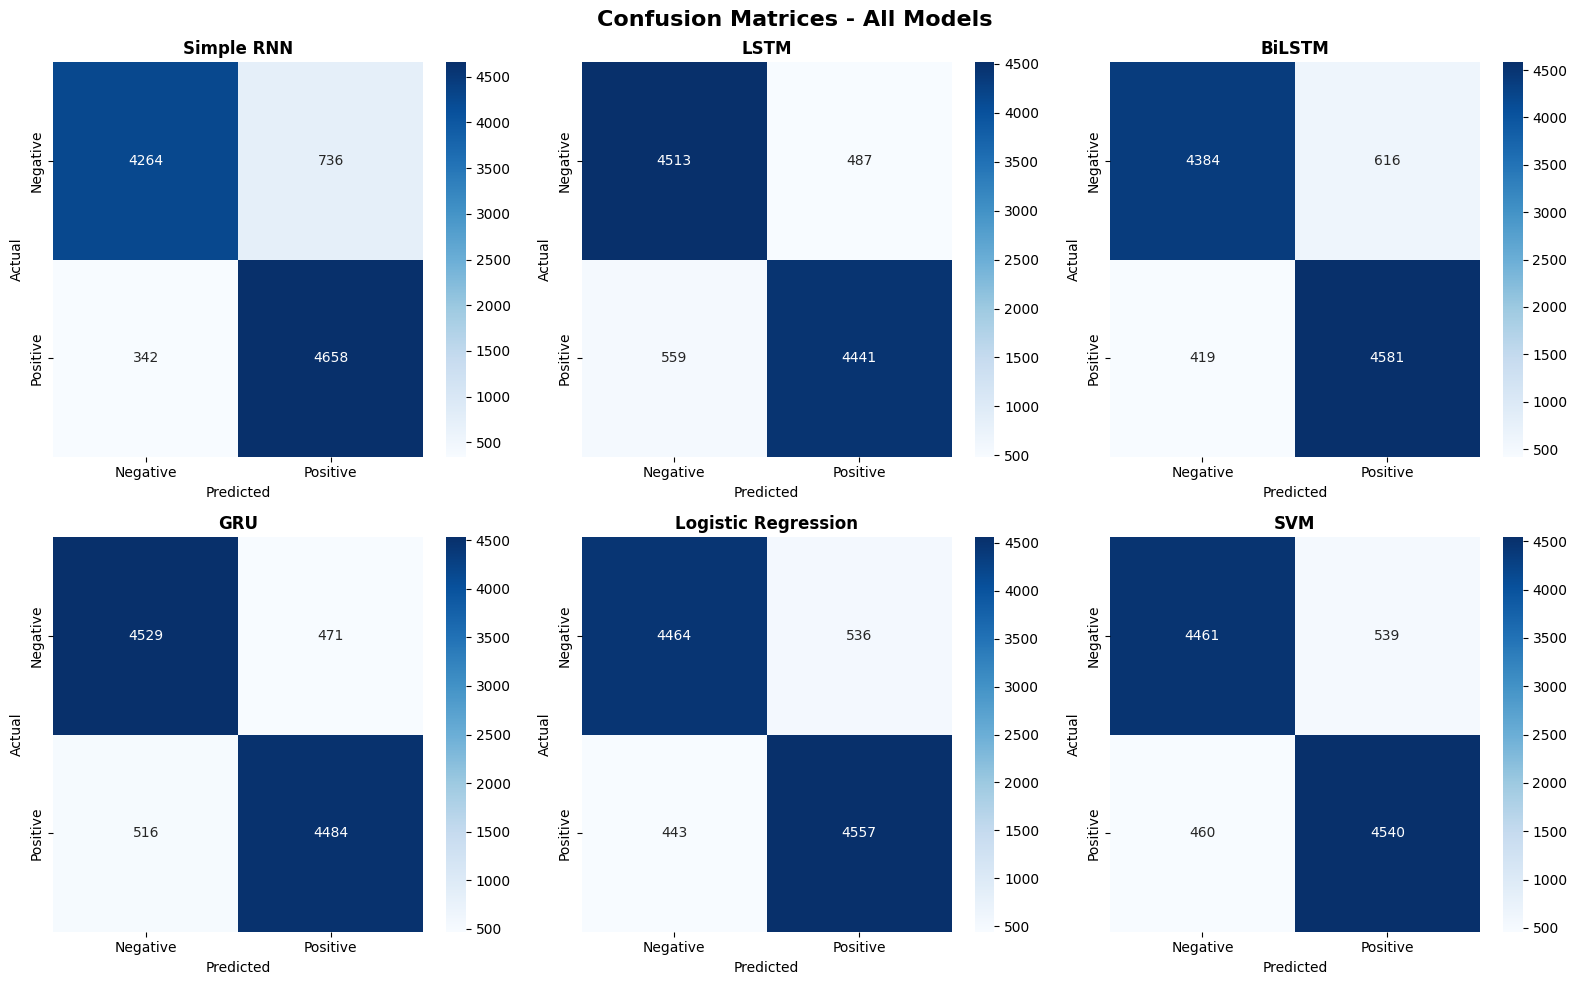

Confusion matrices saved!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')

model_names = ['Simple RNN', 'LSTM', 'BiLSTM', 'GRU', 'Logistic Regression', 'SVM']

for idx, model_name in enumerate(model_names):
    ax = axes[idx//3][idx%3]
    cm = confusion_matrix(y_test, results[model_name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved!")

Simple RNN: Weak at negative recognition

LSTM: Improved negative recognition but increased positive evasion. The balance shifted.

BiLSTM: Balanced the two – neither too much FP nor too much FN

GRU: The model that best recognizes negative interpretations

Logistic Regression: Balanced and low in both error types. The fairest model

SVM: Almost the same profile as LR

Overall Commentary

The smaller the numbers outside the diagonal, the better the model. Looking at the graph, GRU and LR have the darkest diagonal and the lightest error cells — visually confirming their leading position in the metrics table.

## **Training History Graphs**

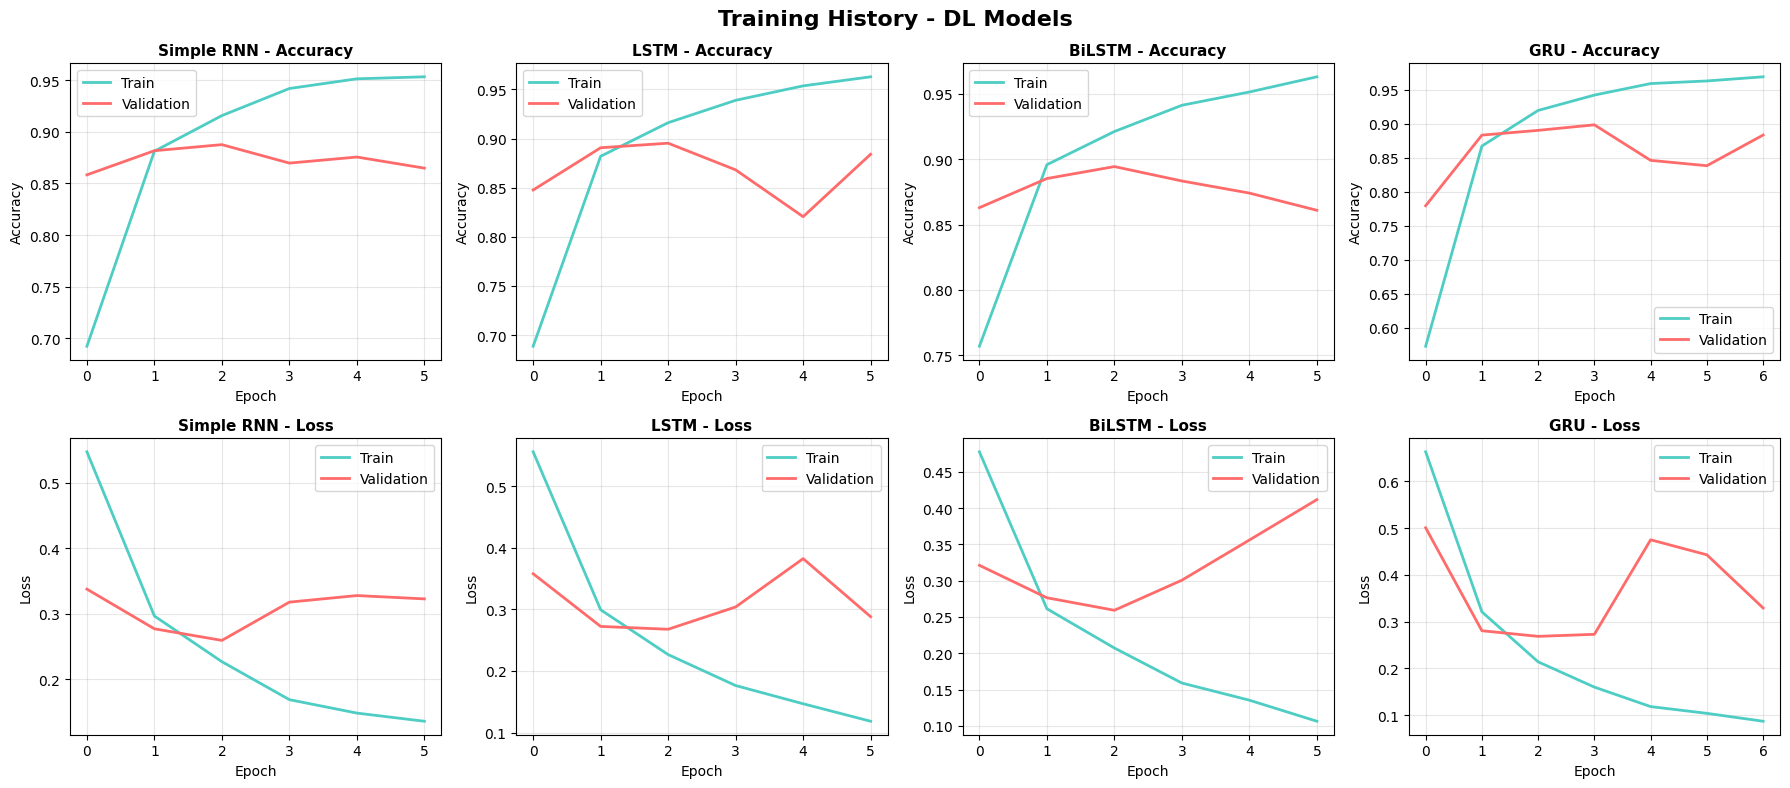

Training history saved!


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Training History - DL Models', fontsize=16, fontweight='bold')

histories = [rnn_history, lstm_history, bilstm_history, gru_history]
dl_names = ['Simple RNN', 'LSTM', 'BiLSTM', 'GRU']

for idx, (history, name) in enumerate(zip(histories, dl_names)):
    # Accuracy plot
    ax1 = axes[0][idx]
    ax1.plot(history.history['accuracy'], label='Train', color='#4ECDC4', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation', color='#FF6B6B', linewidth=2)
    ax1.set_title(f'{name} - Accuracy', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss plot
    ax2 = axes[1][idx]
    ax2.plot(history.history['loss'], label='Train', color='#4ECDC4', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation', color='#FF6B6B', linewidth=2)
    ax2.set_title(f'{name} - Loss', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training history saved!")

Accuracy should increase over time, Loss should decrease over time.

Ideal: The two lines should stay close together and improve together.

Danger!!: Blue improves, red stabilizes or worsens -> overfitting!!

Simple RNN: In the accuracy graph, the blue line jumped from 70% to 95%, while the red line remained flat at 87%. The gap between the two widened significantly – a clear sign of overfitting. The loss graph tells the same story: while training loss approached zero, valuation loss remained flat.

LSTM: Similar pattern. Valuation accuracy dropped sharply in Epoch 4 – the model went into rote learning mode at that point. Early stopping saved the best weights (Epoch 3).

BiLSTM: The first two epochs together performed well, then the gap widened. The valuation loss graph shows a continuous rise after Epoch 3 – a classic sign of overfitting.

GRU: This is the most dramatic graph. In Epoch 1, the red line jumped from 78% to 90% – it learned very quickly. Then, in Epochs 4-5, valuation accuracy plummeted, and loss exploded. Early stopping saved Epoch 4.

Common to all models:

Train loss -> continuously decreasing (blue)

Val loss -> starts to increase at a certain point (red) - beginning of overfitting

## **Sample Predictions**

In [ ]:
# Sample predictions
sample_reviews = [
    "This movie was absolutely amazing! The acting was superb and the story was breathtaking.",
    "Terrible film. Complete waste of time and money. I fell asleep halfway through.",
    "It was okay, nothing special. Some parts were good but overall quite boring.",
    "One of the best movies I have ever seen. Highly recommended to everyone!",
    "The worst movie ever made. Awful acting, terrible script, no plot at all."
]

print("="*70)
print("SAMPLE PREDICTIONS - GRU Model (Best DL Model)")
print("="*70)

for review in sample_reviews:
    cleaned = clean_text(review)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    pred = gru_model.predict(padded, verbose=0)[0][0]
    sentiment = "POSITIVE :)" if pred > 0.5 else "NEGATIVE :()"
    print(f"\nReview: {review[:60]}...")
    print(f"Prediction: {sentiment} (confidence: {pred:.3f})")
print("="*70)

SAMPLE PREDICTIONS - GRU Model (Best DL Model)

Review: This movie was absolutely amazing! The acting was superb and...
Prediction: POSITIVE 😊 (confidence: 0.997)

Review: Terrible film. Complete waste of time and money. I fell asle...
Prediction: NEGATIVE 😞 (confidence: 0.001)

Review: It was okay, nothing special. Some parts were good but overa...
Prediction: NEGATIVE 😞 (confidence: 0.003)

Review: One of the best movies I have ever seen. Highly recommended ...
Prediction: POSITIVE 😊 (confidence: 0.993)

Review: The worst movie ever made. Awful acting, terrible script, no...
Prediction: NEGATIVE 😞 (confidence: 0.001)


The confidence score indicates how confident the model is.

**Attempting to Reduce Overfitting**

To reduce overfitting, we will:

Increase the dropout rate.

Reduce the number of LSTM neurons.

Add L2 regularization (this penalizes overfitting of the model).

Apply only to our best model, the GRU; we don't need to retrain the others. We already have the results.

## **Regularized GRU**

In [ ]:
from tensorflow.keras.regularizers import l2

tf.random.set_seed(42)
np.random.seed(42)

gru_model_v2 = Sequential([
    Embedding(MAX_WORDS, EMBEDDING_DIM,
              weights=[embedding_matrix],
              trainable=True),
    Conv1D(64, 5, activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling1D(5),
    GRU(64, kernel_regularizer=l2(0.001)),
    Dropout(0.6),
    Dense(1, activation='sigmoid')
])

gru_model_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

gru_history_v2 = gru_model_v2.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

evaluate_model(gru_model_v2, X_test_pad, y_test, 'GRU v2')

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5597 - loss: 0.7540 - val_accuracy: 0.7939 - val_loss: 0.5076
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8596 - loss: 0.3850 - val_accuracy: 0.8826 - val_loss: 0.3238
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9082 - loss: 0.2780 - val_accuracy: 0.8859 - val_loss: 0.3002
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9313 - loss: 0.2285 - val_accuracy: 0.8842 - val_loss: 0.3083
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9474 - loss: 0.1866 - val_accuracy: 0.8879 - val_loss: 0.3122
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9568 - loss: 0.1635 - val_accuracy: 0.8424 - val_loss: 0.4765
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9576 - loss: 0.1559 - val_accuracy: 0.8687 - val_loss: 0.4786
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9588 - loss: 0.1548 - val_accu

Restrictions were applied in three directions - the model was both shrunk and penalized, and more neurons were shut down.

Epoch 1: Started slower than original

Epoch 3: Peak

Epoch 6: Set decline

Epoch 8: 3 epochs of no recovery -> stopped

It went up to 8 epochs - it had stopped at 7 in the original. Regularization made the model a bit more "patient" but overfitting didn't completely disappear.

GRUv2 performed worse. Why?

Regularization doesn't always improve performance.

We over-restricted the model. Halving the number of neurons and simultaneously applying L2+ high dropout also limited the model's learning capacity. Overfitting decreased, but it shifted towards underfitting – the model didn't learn enough.

## **BERT Tokenizer and Data Preperation**

I applied BERT to explore the overfitting problem and test the power of transfer learning.

Since BERT is a model pre-trained with billions of English texts, it doesn't need to learn from scratch. Therefore, it can generalize better with less data.

In [ ]:
# Load BERT tokenizer
print("Loading BERT tokenizer...")
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print("Tokenizer loaded!")

# Use subset for speed - 10000 train, 2500 test
X_train_bert = list(X_train[:10000])
X_test_bert = list(X_test[:2500])
y_train_bert = y_train[:10000]
y_test_bert = y_test[:2500]

print("Tokenizing train data...")
train_encodings = bert_tokenizer(
    X_train_bert,
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors='pt'
)

print("Tokenizing test data...")
test_encodings = bert_tokenizer(
    X_test_bert,
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors='pt'
)

# Create datasets
train_dataset = TensorDataset(
    train_encodings['input_ids'],
    train_encodings['attention_mask'],
    torch.tensor(y_train_bert)
)

test_dataset = TensorDataset(
    test_encodings['input_ids'],
    test_encodings['attention_mask'],
    torch.tensor(y_test_bert)
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

print(f"\nTrain samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print("Data ready!")

Loading BERT tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded!
Tokenizing train data...
Tokenizing test data...

Train samples: 10000
Test samples: 2500
Data ready!


This step is where BERT prepares how it "understands" the data — quite different from the GloVe/Tokenizer step.

## **Upload BERT Model and Train**

In [ ]:
print("Loading BERT model...")
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)
bert_model = bert_model.to(device)
print("Model loaded!")

# Optimizer
optimizer = AdamW(bert_model.parameters(), lr=2e-5)

# Training
print("\nTraining BERT...")
bert_model.train()

for epoch in range(3):
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, batch in enumerate(train_loader):
        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        optimizer.zero_grad()
        outputs = bert_model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 100 == 0:
            print(f"Epoch {epoch+1} | Step {batch_idx+1}/{len(train_loader)} | "
                  f"Loss: {total_loss/(batch_idx+1):.4f} | "
                  f"Acc: {correct/total:.4f}")

    print(f"\nEpoch {epoch+1} Complete | "
          f"Avg Loss: {total_loss/len(train_loader):.4f} | "
          f"Train Acc: {correct/total:.4f}\n")

print("Training complete!")

Loading BERT model...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!

Training BERT...
Epoch 1 | Step 100/625 | Loss: 0.5679 | Acc: 0.6687
Epoch 1 | Step 200/625 | Loss: 0.4499 | Acc: 0.7656
Epoch 1 | Step 300/625 | Loss: 0.3969 | Acc: 0.8048
Epoch 1 | Step 400/625 | Loss: 0.3628 | Acc: 0.8283
Epoch 1 | Step 500/625 | Loss: 0.3397 | Acc: 0.8434
Epoch 1 | Step 600/625 | Loss: 0.3209 | Acc: 0.8542

Epoch 1 Complete | Avg Loss: 0.3198 | Train Acc: 0.8559

Epoch 2 | Step 100/625 | Loss: 0.1785 | Acc: 0.9331
Epoch 2 | Step 200/625 | Loss: 0.1640 | Acc: 0.9422
Epoch 2 | Step 300/625 | Loss: 0.1582 | Acc: 0.9440
Epoch 2 | Step 400/625 | Loss: 0.1571 | Acc: 0.9434
Epoch 2 | Step 500/625 | Loss: 0.1542 | Acc: 0.9447
Epoch 2 | Step 600/625 | Loss: 0.1601 | Acc: 0.9416

Epoch 2 Complete | Avg Loss: 0.1594 | Train Acc: 0.9424

Epoch 3 | Step 100/625 | Loss: 0.0709 | Acc: 0.9775
Epoch 3 | Step 200/625 | Loss: 0.0707 | Acc: 0.9766
Epoch 3 | Step 300/625 | Loss: 0.0704 | Acc: 0.9765
Epoch 3 | Step 400/625 | Loss: 0.0790 | Acc: 0.9750
Epoch 3 | Step 500/6

Epoch 1: Started learning from scratch

Epoch 2: A huge leap!

Epoch 3: Almost perfect

Loss halves in each epoch, accuracy increases rapidly. This is the power of transfer learning – it doesn't start from scratch, it comes with a massive knowledge of English and quickly adapts to film reviews.

In Epoch 3, training accuracy was 97.4% – but test results were 90.2%. There's slight overfitting, but that's to be expected with 10,000 samples.

## **BERT Evaluation**

In [ ]:
print("Evaluating BERT...")
bert_model.eval()

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        preds = outputs.logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

results['BERT'] = {
    'accuracy': accuracy_score(all_labels, all_preds),
    'precision': precision_score(all_labels, all_preds),
    'recall': recall_score(all_labels, all_preds),
    'f1': f1_score(all_labels, all_preds),
    'y_pred': all_preds,
    'y_pred_prob': all_probs
}

print("\n" + "="*40)
print("BERT Results:")
print("="*40)
print(f"Accuracy:  {results['BERT']['accuracy']:.4f}")
print(f"Precision: {results['BERT']['precision']:.4f}")
print(f"Recall:    {results['BERT']['recall']:.4f}")
print(f"F1 Score:  {results['BERT']['f1']:.4f}")

Evaluating BERT...

BERT Results:
Accuracy:  0.9024
Precision: 0.8894
Recall:    0.9193
F1 Score:  0.9041


In the Train test, it was 97.4%, and in the Test test, it was 90.2% – this difference indicates overfitting. However, achieving this result with only 10,000 samples proves the power of transfer learning. If trained with 40,000 samples, it would most likely reach 92-93%.

## **Final Comparison Table**

ML models have surpassed DL models. Logistic Regression is first in F1. A simple model is outperforming complex deep networks.

"The results show that traditional machine learning methods (LR, SVM) can perform close to or better than deep learning models with appropriate feature engineering."

Model                       Accuracy  Precision     Recall         F1
Simple RNN                    0.8922     0.8636     0.9316     0.8963
LSTM                          0.8954     0.9012     0.8882     0.8946
BiLSTM                        0.8965     0.8815     0.9162     0.8985
GRU                           0.9013     0.9049     0.8968     0.9009
Logistic Regression           0.9021     0.8948     0.9114     0.9030
SVM                           0.9001     0.8939     0.9080     0.9009
BERT                          0.9024     0.8894     0.9193     0.9041


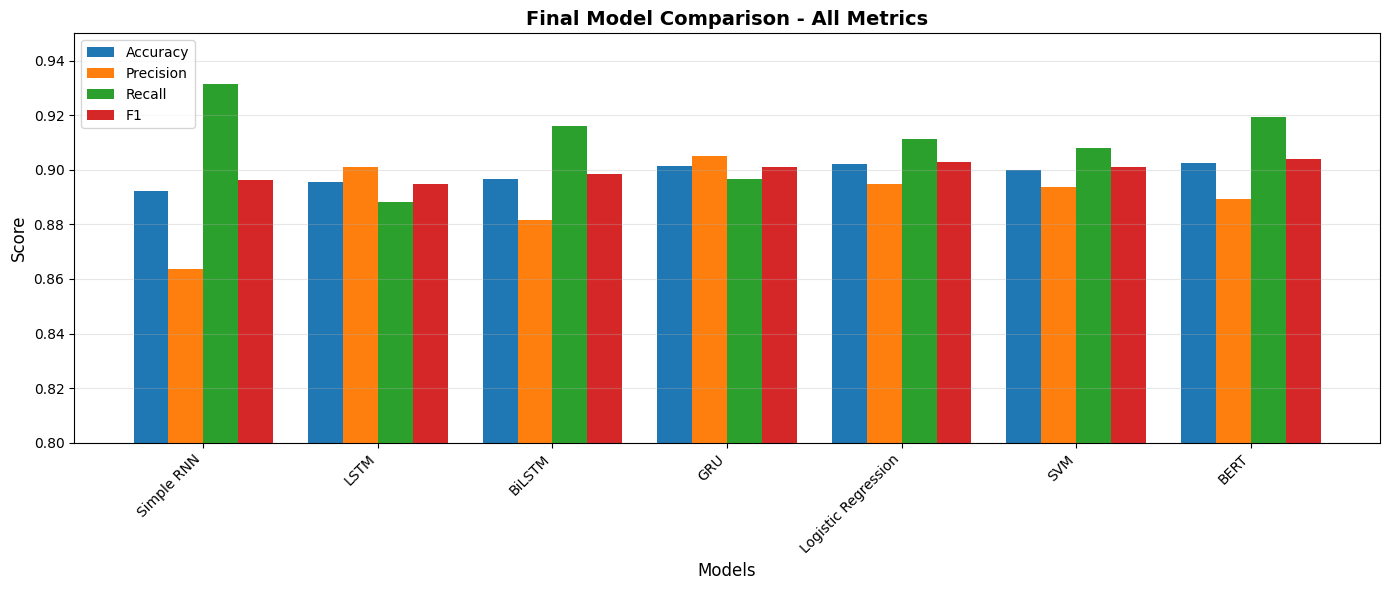

Final comparison saved!


In [ ]:
all_models = ['Simple RNN', 'LSTM', 'BiLSTM', 'GRU',
              'Logistic Regression', 'SVM', 'BERT']

print("="*75)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("="*75)
for model in all_models:
    r = results[model]
    print(f"{model:<25} {r['accuracy']:>10.4f} {r['precision']:>10.4f} "
          f"{r['recall']:>10.4f} {r['f1']:>10.4f}")
print("="*75)

# Bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(all_models))
width = 0.2
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#FF8C00']

metrics = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1']
offsets = [-1.5, -0.5, 0.5, 1.5]

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    values = [results[m][metric] for m in all_models]
    bars = ax.bar(x + offsets[i]*width, values, width, label=label)

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Final Model Comparison - All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(all_models, rotation=45, ha='right')
ax.set_ylim(0.8, 0.95)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final comparison saved!")

## **Learning Curve for ML**

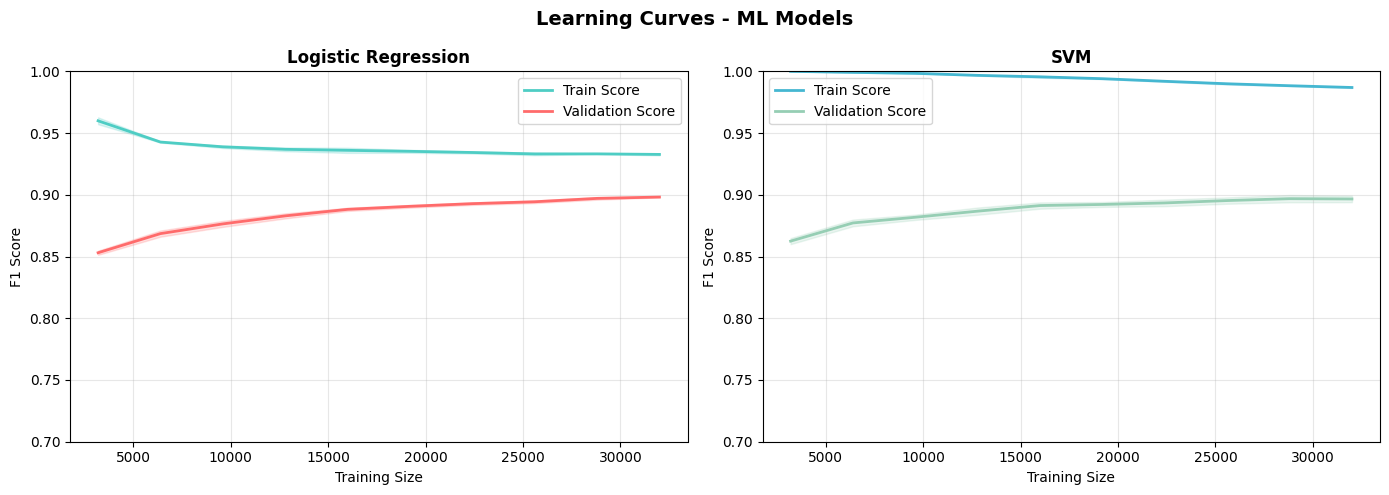

Learning curves saved!


In [ ]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves - ML Models', fontsize=14, fontweight='bold')

ml_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': LinearSVC(max_iter=1000, random_state=42)
}

colors = [('#4ECDC4', '#FF6B6B'), ('#45B7D1', '#96CEB4')]

for idx, (name, model) in enumerate(ml_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_tfidf, y_train,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    ax = axes[idx]
    ax.plot(train_sizes, train_mean, color=colors[idx][0],
            linewidth=2, label='Train Score')
    ax.fill_between(train_sizes, train_mean - train_std,
                    train_mean + train_std, alpha=0.2, color=colors[idx][0])
    ax.plot(train_sizes, val_mean, color=colors[idx][1],
            linewidth=2, label='Validation Score')
    ax.fill_between(train_sizes, val_mean - val_std,
                    val_mean + val_std, alpha=0.2, color=colors[idx][1])

    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Training Size')
    ax.set_ylabel('F1 Score')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.7, 1.0)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Learning curves saved!")

Would it learn better if I provided more data?

Logistic Regression: The two lines are converging – providing more data strengthens the model and reduces overfitting.

SVM: The training score remained stable at 99% – SVM memorizes the training data almost perfectly. However, validation also improves, meaning new data is still useful.